In [1]:
import os
import re

from datetime import datetime, timedelta

import json
import pickle

from multiprocessing import Pool

import subprocess

from PIL import Image
import pillow_heif

pillow_heif.register_heif_opener()

import matplotlib.pyplot as plt

import numpy as np
import pandas as pd

from tqdm import tqdm

from joblib import Parallel, delayed

In [2]:
path = "/Users/nicolaepopescul/code/streams/py8tb/data/df_2026_08_16_15_59_54.csv"

In [3]:
df = pd.read_csv(path)

In [4]:
(
    df
    .groupby(["FileExtension"])
    .size()
    .sort_values(ascending=False)
)

FileExtension
.mp4     2564
.heic    1861
.jpg     1547
.mov      588
.png       53
.jpeg       1
.m4v        1
dtype: int64

In [5]:
def extract_exif_metadata(file_path, verbose = False):
    
    result = subprocess.run(
        [
            "exiftool",
            "-j",
            file_path,
        ],
        capture_output=True,
        text=True,
        check=False,
    )
    
    if verbose: print(result)
        
    return file_path, result

In [6]:
def plot_photo(file_path):
    img = np.asarray(Image.open(file_path))
    imgplot = plt.imshow(img)

file_paths = df["FilePath"].tolist()
RESULT_DICT = {}

results = Parallel(n_jobs=8)(
    delayed(extract_exif_metadata)(file_path)
    for file_path in tqdm(file_paths, desc="Extracting EXIF")
)

RESULT_DICT = dict(results)

with open('exif_metadata.pkl', 'wb') as f:
    pickle.dump(RESULT_DICT, f)

In [7]:
with open("exif_metadata.pkl", "rb") as f:
    exif_metadata_full = pickle.load(f)

In [8]:
# json.loads(exif_metadata["/Volumes/MUPU_3/testing/DJI_20260731203138_0089_D.MP4"].stdout)[0]

In [9]:
# ! exiftool "/Volumes/MUPU_3/testing/IMG_3847.MOV"

In [10]:
def extract_dji_creation_date_from_filepath(file_path):
    basename = os.path.basename(file_path)
    match = re.match(
        r"DJI_(\d{14})_",
        basename,
        re.IGNORECASE
    )
    return match

def extract_dji_mimo_creation_date_from_filepath(file_path):
    basename = os.path.basename(file_path)

    match = re.search(
        r"dji_mimo_(\d{8})_(\d{6})_",
        basename,
        re.IGNORECASE
    )

    return match

def extract_dji_mimo_creation_date_from_original_filepath(file_path):
    basename = os.path.basename(file_path)

    match = re.search(
        r"DJI_(\d{8})(\d{6})_",
        basename,
        re.IGNORECASE
    )

    return match

In [13]:
UUID_PATTERN = re.compile(
    r"^[0-9a-fA-F]{8}-"
    r"[0-9a-fA-F]{4}-"
    r"[1-5][0-9a-fA-F]{3}-"
    r"[89abAB][0-9a-fA-F]{3}-"
    r"[0-9a-fA-F]{12}$"
)

def is_uuid_in_filepath(file_path):
    basename = os.path.basename(file_path).split(".")[0]
    return bool(UUID_PATTERN.fullmatch(basename))

In [14]:
exif_metadata = {}

for file_path, metadata in exif_metadata_full.items():
    if not is_uuid_in_filepath(file_path):
        exif_metadata[file_path] = metadata

In [15]:
len(exif_metadata_full)

6616

In [16]:
len(exif_metadata)

6422

In [18]:
processed = {}
not_processed = []

for file_path, metadata in exif_metadata.items():
    
    json_contents = json.loads(exif_metadata[file_path].stdout)[0]
            
    if "DJI" in file_path:
        
        match = extract_dji_creation_date_from_filepath(file_path=json_contents["SourceFile"])
        
        if match:
            processed[file_path] = match.group(1)
            
    elif "dji_mimo" in file_path:
        match =\
        extract_dji_mimo_creation_date_from_original_filepath(file_path=json_contents["SourceFile"])
        
        if match:
            processed[file_path] = "".join(match.groups())
            
        elif "OriginalFilePath" in json_contents:
            match =\
            extract_dji_mimo_creation_date_from_original_filepath(file_path=json_contents["OriginalFilePath"])

            if match:
                processed[file_path] = "".join(match.groups())
                    
        else:
            match =\
            extract_dji_mimo_creation_date_from_filepath(file_path=json_contents["SourceFile"])
            
            if match:
                processed[file_path] = "".join(match.groups())
                
            else:
                not_processed.append(file_path)
        
    elif "Make" in json_contents.keys():
        maker = json_contents["Make"]
        
        if maker == "Apple":
            
            if ".MOV" in file_path:
                creation_date =\
                datetime.strptime(json_contents["CreationDate"], "%Y:%m:%d %H:%M:%S%z").strftime("%Y%m%d%H%M%S")

                processed[file_path] = creation_date
            
            elif (".JPG" in file_path or ".HEIC" in file_path):
                creation_date =\
                datetime.strptime(json_contents["CreateDate"], "%Y:%m:%d %H:%M:%S").strftime("%Y%m%d%H%M%S")

                processed[file_path] = creation_date
            
        if maker == "AKASO":
            
            if ".JPG" in file_path:
                
                creation_date = json_contents["CreateDate"]
                creation_date = datetime.strptime(creation_date, "%Y:%m:%d %H:%M:%S")
                creation_date += timedelta(hours=7)

                creation_date = creation_date.strftime("%Y%m%d%H%M%S")
                
                processed[file_path] = creation_date
                

    # videos de AKASO
    elif ".MOV" in file_path:
        creation_date = json_contents["FileModifyDate"]
        creation_date = datetime.strptime(creation_date, "%Y:%m:%d %H:%M:%S%z")
        creation_date += timedelta(hours=7)

        creation_date = creation_date.strftime("%Y%m%d%H%M%S")

        processed[file_path] = creation_date
            
    else:
        not_processed.append(file_path)

In [19]:
len(processed)

6330

In [20]:
len(not_processed)

85

In [21]:
str(round((len(processed)/len(exif_metadata)) * 100, 2)) + "%"

'98.57%'

In [22]:
assert (len(processed) + len(not_processed)) == len(exif_metadata), f"You missed {len(exif_metadata) - len(processed) - len(not_processed)} files!"

AssertionError: You missed 7 files!

In [23]:
[f for f in exif_metadata.keys() if f not in list(processed.keys()) + not_processed]

['/Volumes/MUPU_3/testing/QOKDE2403.JPG',
 '/Volumes/MUPU_3/testing/FZSWE5336.JPG',
 '/Volumes/MUPU_3/testing/OLGLE5593.JPG',
 '/Volumes/MUPU_3/testing/IXUWE7506.JPG',
 '/Volumes/MUPU_3/testing/BVARE9386.JPG',
 '/Volumes/MUPU_3/testing/OYCNE4222.JPG',
 '/Volumes/MUPU_3/testing/CZBTE5759.JPG']

In [24]:
for file_path in not_processed:
    print(file_path)

/Volumes/MUPU_3/testing/IMG_4266.PNG
/Volumes/MUPU_3/testing/dji_mimo_0_0_0_1784974537691.JPG
/Volumes/MUPU_3/testing/PIXEL.JPEG
/Volumes/MUPU_3/testing/dji_mimo_0_0_0_1784974598310.JPG
/Volumes/MUPU_3/testing/IMG_4267.PNG
/Volumes/MUPU_3/testing/dji_mimo_0_0_0_1784974537732.JPG
/Volumes/MUPU_3/testing/IMG_4265.PNG
/Volumes/MUPU_3/testing/dji_mimo_0_0_0_1786062568508.JPG
/Volumes/MUPU_3/testing/IMG_5787.PNG
/Volumes/MUPU_3/testing/.DS_Store
/Volumes/MUPU_3/testing/dji_mimo_0_0_0_1786026220925.JPG
/Volumes/MUPU_3/testing/dji_mimo_0_0_0_1784974016322.JPG
/Volumes/MUPU_3/testing/VID_20170405_154942.MP4
/Volumes/MUPU_3/testing/IMG_4761.PNG
/Volumes/MUPU_3/testing/IMG_4563.PNG
/Volumes/MUPU_3/testing/VID_20170507_115920.MP4
/Volumes/MUPU_3/testing/dji_mimo_0_0_0_1784974571513.JPG
/Volumes/MUPU_3/testing/IMG_4588.PNG
/Volumes/MUPU_3/testing/IMG_4601.PNG
/Volumes/MUPU_3/testing/IMG_5292.PNG
/Volumes/MUPU_3/testing/IMG_4600.PNG
/Volumes/MUPU_3/testing/IMG_4589.PNG
/Volumes/MUPU_3/testing/IMG_4

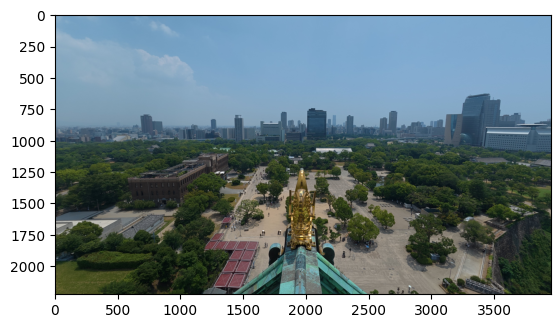

In [26]:
plot_photo("/Volumes/MUPU_3/testing/dji_mimo_0_0_0_1784974571513.JPG")

In [27]:
p = "/Volumes/MUPU_3/testing/dji_mimo_0_0_0_1784974571513.JPG"
j = json.loads(exif_metadata[p].stdout)[0]
j

{'SourceFile': '/Volumes/MUPU_3/testing/dji_mimo_0_0_0_1784974571513.JPG',
 'ExifToolVersion': 13.36,
 'FileName': 'dji_mimo_0_0_0_1784974571513.JPG',
 'Directory': '/Volumes/MUPU_3/testing',
 'FileSize': '1319 kB',
 'FileModifyDate': '2026:07:23 05:49:14+02:00',
 'FileAccessDate': '2026:08:16 16:43:29+02:00',
 'FileInodeChangeDate': '2026:08:15 20:14:18+02:00',
 'FilePermissions': '-rw-------',
 'FileType': 'JPEG',
 'FileTypeExtension': 'jpg',
 'MIMEType': 'image/jpeg',
 'ExifByteOrder': 'Little-endian (Intel, II)',
 'ImageDescription': 'default',
 'Make': 'DJI',
 'Model': 'AC006',
 'Orientation': 'Horizontal (normal)',
 'XResolution': 72,
 'YResolution': 72,
 'ResolutionUnit': 'inches',
 'Software': '10.00.34.36',
 'ModifyDate': '2026:07:23 05:49:14',
 'YCbCrPositioning': 'Co-sited',
 'ExposureTime': '1/2000',
 'FNumber': 2.8,
 'ExposureProgram': 'Program AE',
 'ISO': 150,
 'SensitivityType': 'Recommended Exposure Index',
 'RecommendedExposureIndex': 150,
 'ExifVersion': '0230',
 'Da